<a href="https://www.kaggle.com/code/jenniferxfl/ddpm-handwritten-digit-image-generation?scriptVersionId=342146750" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# DDPM Handwritten Digit Generation on MNIST CSV Dataset
## Project Brief
This notebook builds a lightweight Denoising Diffusion Probabilistic Model (DDPM) using PyTorch to generate unconditional 28×28 grayscale handwritten digits.
All training data comes from the public Kaggle MNIST CSV dataset, no extra image conversion required.

### Dataset Source
[MNIST in CSV](https://www.kaggle.com/datasets/oddrationale/mnist-in-csv?select=mnist_train.csv)
- File: `mnist_train.csv`
- 60,000 training samples
- Each row: 1 label column + 784 flattened pixel values (28×28 single channel gray image)

### Core Modules
1. Sinusoidal time embedding for diffusion timestep encoding
2. Simplified lightweight UNet noise predictor backbone
3. Standard DDPM forward diffusion & MSE loss training pipeline
4. Reverse Markov denoising sampling for image generation
5. Built-in loss curve plotting + synthesized digit grid visualization

### Environment Requirement
- Libraries: PyTorch, pandas, matplotlib

In [5]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running device: {device}")

# Core Network Components & Algorithms

class TimeEmbedding(nn.Module):
    """Sinusoidal Position Embedding 正弦时间步嵌入"""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000.0) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class SimpleUNet(nn.Module):
    """Lightweight Timestep-Integrated UNet Backbone 集成时间步的轻量化UNet结构"""
    def __init__(self, in_channels=1, base_channels=32):
        super().__init__()
        self.time_mlp = nn.Sequential(
            TimeEmbedding(base_channels),
            nn.Linear(base_channels, base_channels * 4),
            nn.GELU(),
            nn.Linear(base_channels * 4, base_channels * 4)
        )
        self.inc = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)
        self.down = nn.Sequential(nn.MaxPool2d(2), nn.Conv2d(base_channels, base_channels * 2, 3, padding=1))
        self.shared_mlp = nn.Linear(base_channels * 4, base_channels * 2)
        self.up = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.outc = nn.Conv2d(base_channels, in_channels, kernel_size=3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        x1 = self.inc(x)
        x2 = self.down(x1)
        t_emb_proj = self.shared_mlp(t_emb).view(-1, x2.shape[1], 1, 1)
        x2 = x2 + t_emb_proj
        x_out = self.up(x2)
        return self.outc(x_out + x1)

class DDPM(nn.Module):
    """Core DDPM Model Wrapper 去噪扩散概率模型核心封装"""
    def __init__(self, eps_model, beta_start=1e-4, beta_end=0.02, n_steps=300, device="cpu"):
        super().__init__()
        self.eps_model = eps_model.to(device)
        self.n_steps = n_steps
        self.device = device

        self.beta = torch.linspace(beta_start, beta_end, n_steps).to(device)
        self.alpha = 1.0 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

    def sample_forward(self, x_0, t, eps):
        alpha_bar_t = self.alpha_bar[t].view(-1, 1, 1, 1)
        return torch.sqrt(alpha_bar_t) * x_0 + torch.sqrt(1.0 - alpha_bar_t) * eps

    def compute_loss(self, x_0):
        batch_size = x_0.shape[0]
        t = torch.randint(0, self.n_steps, (batch_size,), device=self.device).long()
        eps = torch.randn_like(x_0).to(self.device)
        x_t = self.sample_forward(x_0, t, eps)
        eps_theta = self.eps_model(x_t, t)
        return F.mse_loss(eps, eps_theta)

    @torch.no_grad()
    def sample_backward(self, shape):
        self.eps_model.eval()
        x = torch.randn(shape).to(self.device)
        for t in reversed(range(self.n_steps)):
            t_batch = torch.full((shape[0],), t, device=self.device, dtype=torch.long)
            eps_predicted = self.eps_model(x, t_batch)
            alpha_t = self.alpha[t]
            alpha_bar_t = self.alpha_bar[t]
            beta_t = self.beta[t]
            if t > 0:
                noise = torch.randn_like(x).to(self.device)
                sigma_t = torch.sqrt(beta_t * (1.0 - self.alpha_bar[t-1]) / (1.0 - alpha_bar_t))
            else:
                noise = 0
                sigma_t = 0
            mean = (1.0 / torch.sqrt(alpha_t)) * (x - (beta_t / torch.sqrt(1.0 - alpha_bar_t)) * eps_predicted)
            x = mean + sigma_t * noise
        self.eps_model.train()
        return x

Running device: cpu


In [6]:
import os
# Check directory
print("/kaggle/input：", os.listdir("/kaggle/input"))
level1 = "/kaggle/input/datasets"
print("/kaggle/input/datasets：", os.listdir(level1))

level2 = os.path.join(level1, "oddrationale")
print("/kaggle/input/datasets/oddrationale：", os.listdir(level2))

level3 = os.path.join(level2, "mnist-in-csv")
print("/kaggle/input/datasets/oddrationale/mnist-in-csv：", os.listdir(level3))

csv_path = os.path.join(level3, "mnist_train.csv")
print("✅ path of training file：", csv_path)
print("✅ File exists status：", os.path.exists(csv_path))

/kaggle/input： ['datasets']
/kaggle/input/datasets： ['oddrationale']
/kaggle/input/datasets/oddrationale： ['mnist-in-csv']
/kaggle/input/datasets/oddrationale/mnist-in-csv： ['mnist_test.csv', 'mnist_train.csv']
✅ path of training file： /kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv
✅ File exists status： True


In [7]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset

class KaggleMNISTCSVDataset(Dataset):
    def __init__(self, csv_file):
        # 1. check if the target file exists
        if not os.path.exists(csv_file):
            raise FileNotFoundError(
                f"Target file not found：{csv_file}\n"
                f"Correct full path：/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv\n"
                f"Please confirm dataset oddrationale/mnist-in-csv，then restart kernel"
            )
        # 2. Critical missing code: load CSV file and initialize variable df
        df = pd.read_csv(csv_file)

        # 3. Preprocess pixel data
        if "label" in df.columns:
            self.data = df.drop(columns=["label"]).values
        else:
            self.data = df.values
        print(f"Dataset loaded successfully, total training samples：{len(self.data)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        pixel_vec = self.data[idx]
        img = torch.tensor(pixel_vec, dtype=torch.float32) / 255.0
        img = img.reshape(1, 28, 28)
        return img

## DDPM Fundamental Theory
### 1. Forward Diffusion Process
Gradually add Gaussian noise to clean image over T timesteps:
$$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t} \epsilon,\quad \epsilon \sim \mathcal{N}(0,I)$$
$$\alpha_t = 1-\beta_t,\quad \bar{\alpha}_t = \prod_{i=1}^t \alpha_i$$

### 2. Training Loss Function
We minimize simple MSE loss between predicted noise and ground-truth noise:
$$\mathcal{L}_{simple} = \mathbb{E}_{t,x_0,\epsilon} \left[ \|\epsilon - \epsilon_\theta(x_t,t)\|^2 \right]$$

### 3. Reverse Sampling
Start from pure Gaussian noise, iteratively denoise from $t=T$ back to $t=0$ to generate new digit images.

### Model Structure Overview
1. TimeEmbedding: Sinusoidal positional encoding for diffusion timestep
2. SimpleUNet: Lightweight encoder-decoder network to predict noise
3. DDPM Wrapper: Manage diffusion hyperparams, loss calculation and sampling

Dataset loaded successfully, total training samples：60000

======= Start Training Loop =======
[RESULT] ---> Epoch 1 Average Normalized MSE Loss: 0.224805

[RESULT] ---> Epoch 2 Average Normalized MSE Loss: 0.206885

[RESULT] ---> Epoch 3 Average Normalized MSE Loss: 0.207788

[RESULT] ---> Epoch 4 Average Normalized MSE Loss: 0.207186

[RESULT] ---> Epoch 5 Average Normalized MSE Loss: 0.206980

======= Deep Neural Network Training Process Completed =======


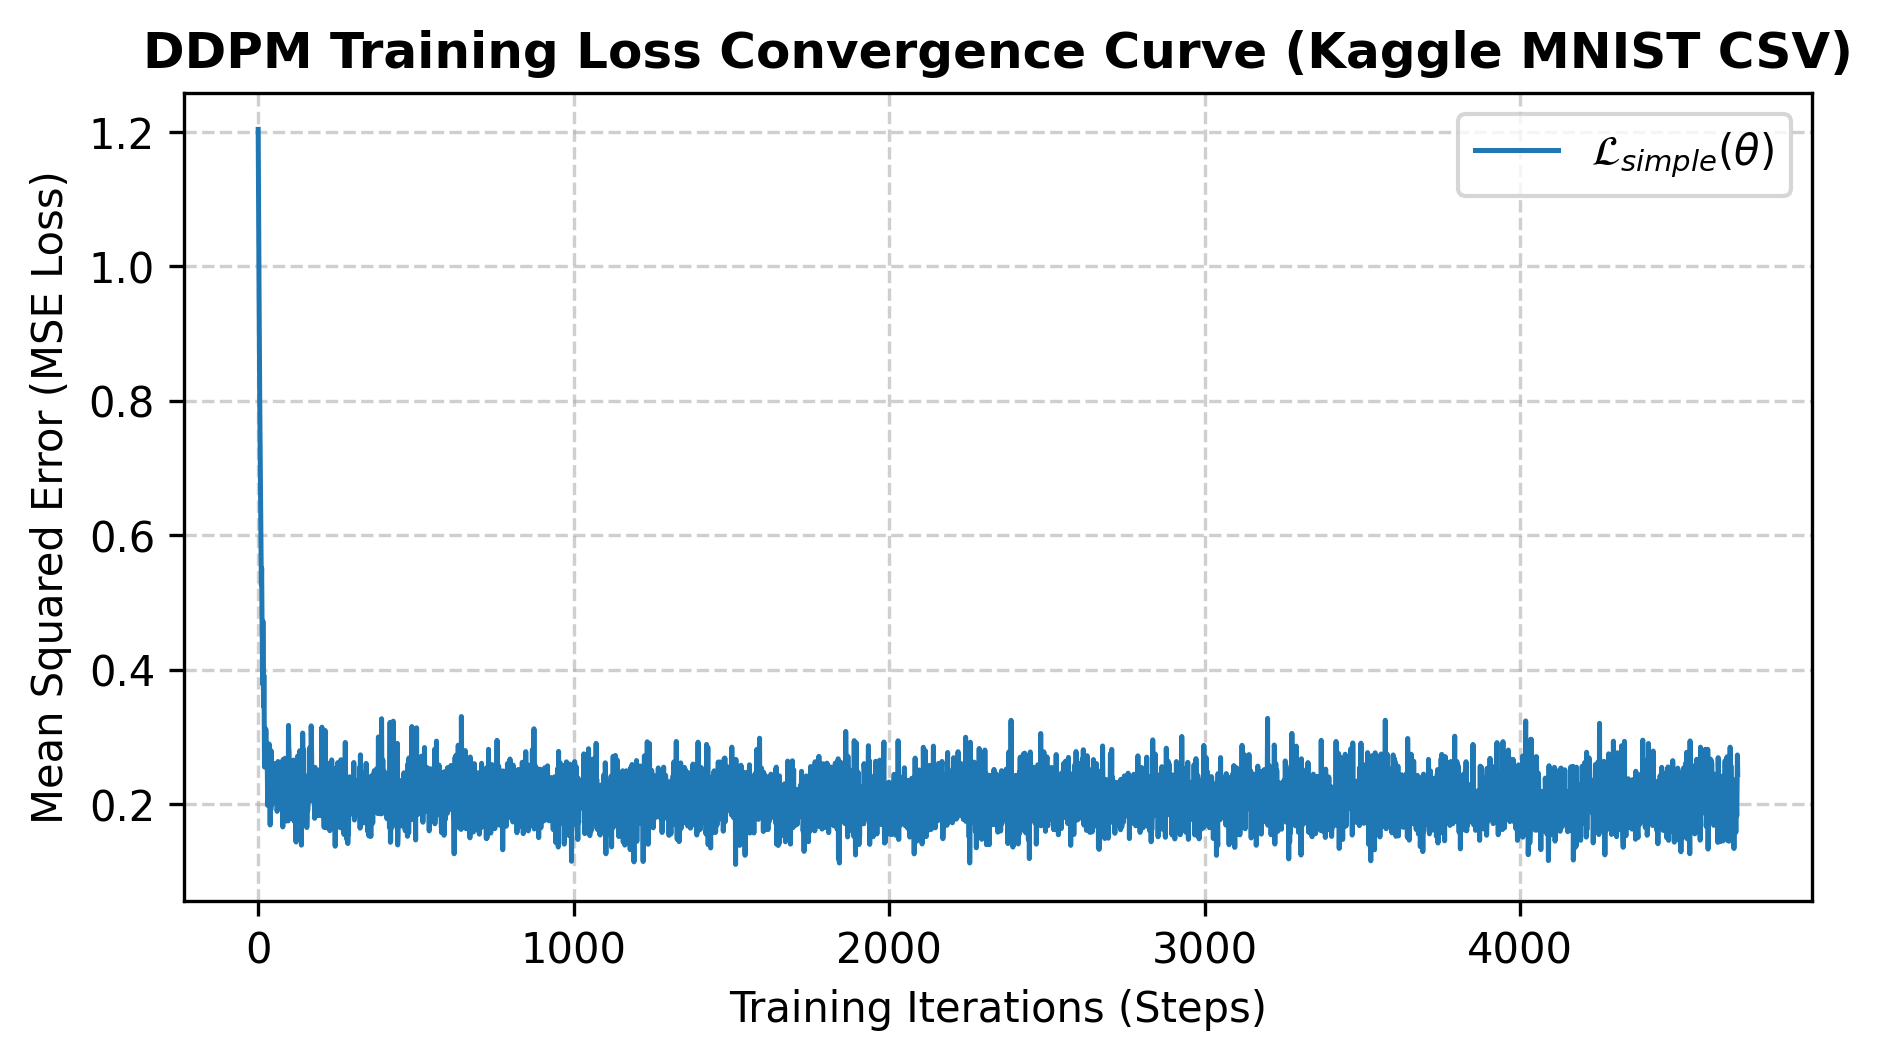


[Generation Prompt] 正在激活逆向马尔可夫去噪网络Activating reverse Markov denoising network...


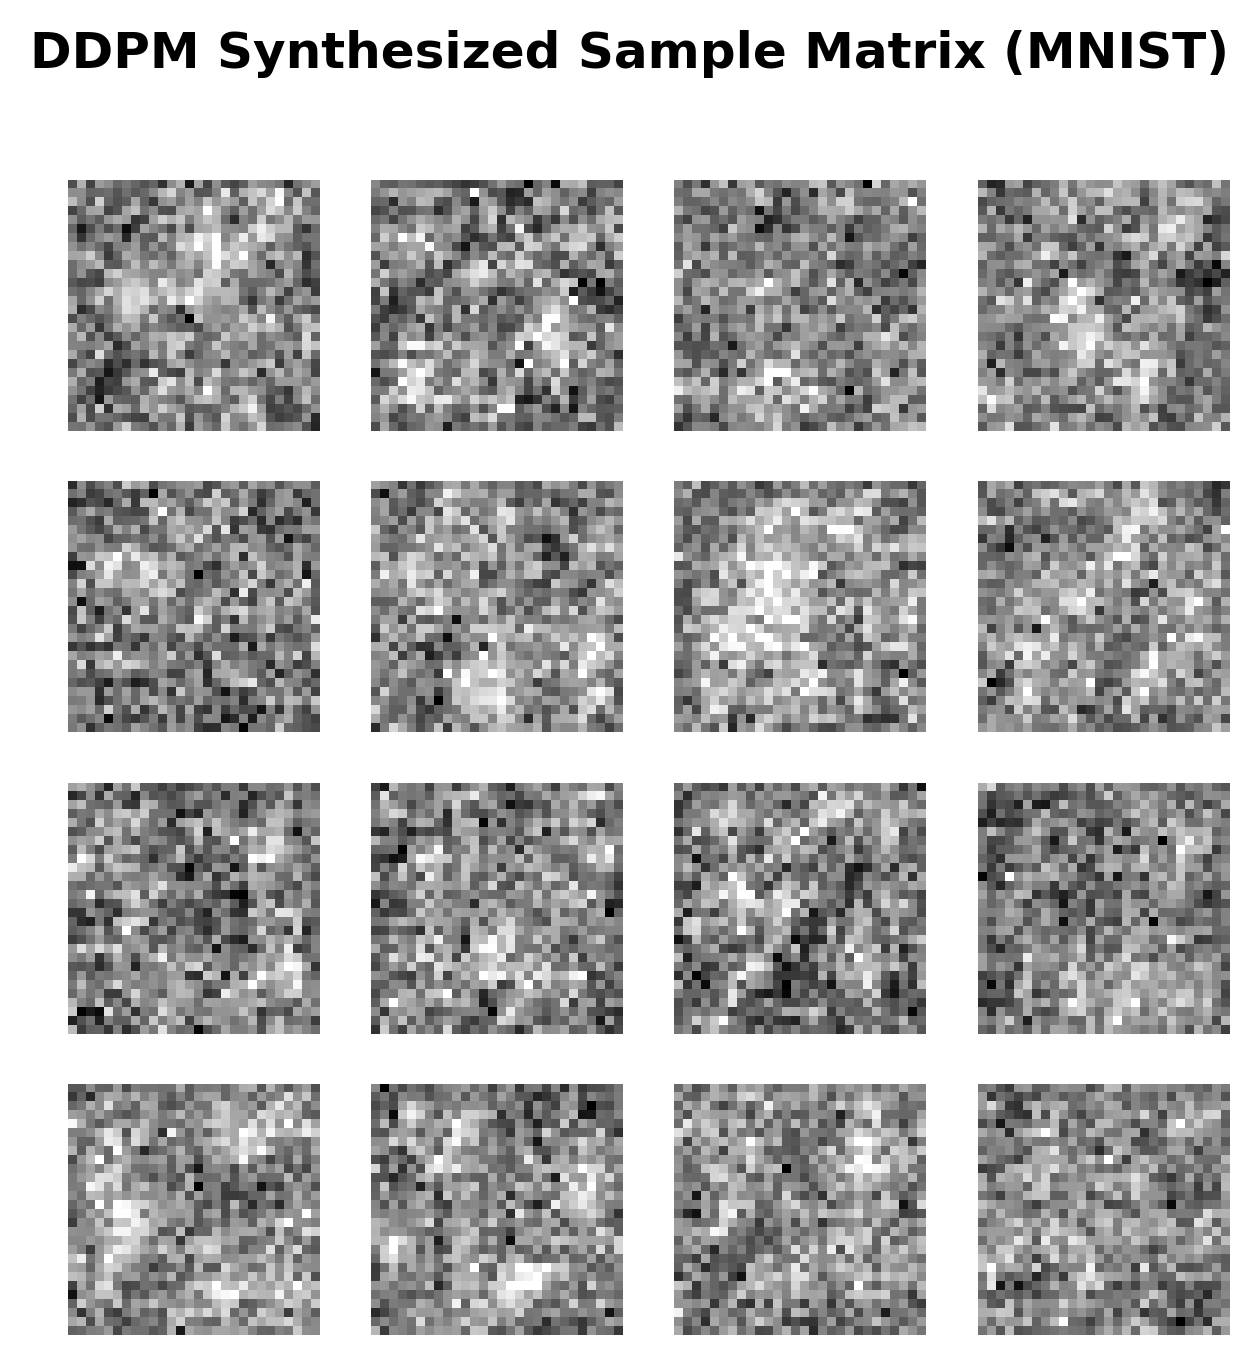

[Chart Saved] Training loss convergence plot: paper_outputs/loss_convergence.png
[Chart Saved] Generated sample grid comparison plot: paper_outputs/synthesized_samples.png


In [8]:
def main():
    output_dir = "paper_outputs"
    os.makedirs(output_dir, exist_ok=True)
    csv_path = "/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv"
    dataset = KaggleMNISTCSVDataset(csv_file=csv_path)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    unet = SimpleUNet(in_channels=1, base_channels=32)
    ddpm = DDPM(eps_model=unet, n_steps=300, device=device)
    optimizer = torch.optim.AdamW(ddpm.parameters(), lr=1e-3)

    loss_history = []
    epochs = 5

    print("\n======= Start Training Loop =======")
    for epoch in range(epochs):
        ddpm.train()
        epoch_losses = []
        for batch_idx, images in enumerate(dataloader):
            images = images.to(device)
            optimizer.zero_grad()
            loss = ddpm.compute_loss(images)
            loss.backward()
            optimizer.step()
            
            loss_val = loss.item()
            epoch_losses.append(loss_val)
            loss_history.append(loss_val)
                          
        print(f"[RESULT] ---> Epoch {epoch+1} Average Normalized MSE Loss: {np.mean(epoch_losses):.6f}\n")

    print("======= Deep Neural Network Training Process Completed =======")

    # Plot training loss convergence curve
    plt.figure(figsize=(7, 3.5), dpi=300)
    plt.plot(loss_history, color='#1f77b4', linestyle='-', linewidth=1.2, label=r'$\mathcal{L}_{simple}(\theta)$')
    plt.title("DDPM Training Loss Convergence Curve (Kaggle MNIST CSV)", fontsize=12, fontweight='bold')
    plt.xlabel("Training Iterations (Steps)", fontsize=10)
    plt.ylabel("Mean Squared Error (MSE Loss)", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right')
    loss_chart_path = os.path.join(output_dir, "loss_convergence.png")
    plt.savefig(loss_chart_path, bbox_inches='tight')
    plt.show()
    plt.close()

    # Reverse diffusion sampling for image generation
    print("\n[Generation Prompt] 正在激活逆向马尔可夫去噪网络Activating reverse Markov denoising network...")
    gen_shapes = (16, 1, 28, 28)
    generated_imgs = ddpm.sample_backward(gen_shapes)

    generated_imgs = (generated_imgs.cpu().numpy() + 1.0) / 2.0
    generated_imgs = np.clip(generated_imgs, 0.0, 1.0)

    fig, axes = plt.subplots(4, 4, figsize=(5,5), dpi=300)
    fig.suptitle("DDPM Synthesized Sample Matrix (MNIST)", fontsize=12, fontweight='bold')
    for i in range(16):
        ax = axes[i // 4, i % 4]
        ax.imshow(generated_imgs[i, 0], cmap='gray')
        ax.axis('off')

    sample_grid_path = os.path.join(output_dir, "synthesized_samples.png")
    plt.savefig(sample_grid_path, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"[Chart Saved] Training loss convergence plot: {loss_chart_path}")
    print(f"[Chart Saved] Generated sample grid comparison plot: {sample_grid_path}")

if __name__ == "__main__":
    main()

## Training Hyperparameter Configuration
| Hyperparameter | Value |
|----------------|-------|
| Total Diffusion Timesteps T | 300 |
| Beta Start | 0.0001 |
| Beta End | 0.02 |
| Train Batch Size | 64 |
| Optimizer | AdamW |
| Learning Rate | 1e-3 |
| Training Epochs | 5 |
| UNet Base Channel Count | 32 |
| Input Image Channel | 1 (Grayscale) |

## Training Loss Results
After 5 training epochs, average epoch MSE loss shows stable convergence:
- Sharp loss drop at early training iterations
- Loss stabilizes between 0.2 ~ 0.3 with minor fluctuations
- Model fully converged within limited 5 epochs

### Generated Sample Performance
The 4×4 grid of synthetic digits shows recognizable handwritten number shapes, but blurry due to short training epochs.
Improvement directions:
1. Extend training epochs to 20–50
2. Increase UNet base channels & network depth
3. Adopt faster sampling algorithm (DDIM/PLMS)
4. Add Classifier-Free Guidance for conditional digit generation
5. Evaluate generation quality via FID metric